# Assignment 6 - House Price Prediction

## Complete ML Pipeline: EDA, Data Preparation, Model Training, Tuning and Persistence

This notebook implements the complete machine learning workflow for house price prediction using the Ames Housing dataset.

The workflow covers dataset inspection, exploratory data analysis, data cleaning, feature engineering, preprocessing, model comparison, hyperparameter tuning, final evaluation, and model persistence.

## 1. Import Required Libraries

We begin by importing the Python libraries required for data loading, analysis, visualization, and basic statistical exploration.

In [1]:
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from app.preprocessing import feature_engineering

## 2. Load and Save the Raw Dataset

The Ames Housing dataset is obtained from OpenML and saved locally as a CSV file.

If the CSV file already exists, it is loaded directly from the local `data/` directory to avoid downloading the dataset again.

In [3]:
DATA_DIR = "../data"
RAW_DATA_PATH = os.path.join(DATA_DIR, "house_prices.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(RAW_DATA_PATH):
    df = pd.read_csv(RAW_DATA_PATH)
    print("Dataset loaded from local CSV:")
    print(RAW_DATA_PATH)
else:
    housing = fetch_openml(
        name="house_prices",
        as_frame=True,
        parser="auto"
    )

    df = housing.frame.copy()
    df.to_csv(RAW_DATA_PATH, index=False)

    print("Dataset downloaded from OpenML and saved to:")
    print(RAW_DATA_PATH)

print("\nDataset shape:", df.shape)

Dataset loaded from local CSV:
../data\house_prices.csv

Dataset shape: (1460, 81)


## 3. Dataset Inspection and Exploratory Data Analysis

### Objective

The objective of this notebook is to understand and analyze the Ames Housing dataset before building the machine learning pipeline.

The analysis includes:
- Loading the dataset
- Understanding its structure and data types
- Checking missing values and duplicate records
- Separating numerical and categorical features
- Analyzing the target variable
- Exploring feature distributions and relationships
- Identifying potential data-cleaning and preprocessing requirements

The observations from this notebook will be used to design the data cleaning, feature engineering, preprocessing, and machine learning pipeline.

## 3.1 Basic Dataset Information

We inspect the number of observations and features to understand the overall size of the dataset.


In [4]:

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

DATASET SHAPE
Number of rows    : 1460
Number of columns : 81


## 3.2 Preview the Dataset

The first and last few records are displayed to understand the structure and values present in the dataset.

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


## 3.3 Dataset Information and Data Types

The dataset information is examined to identify the data types of each feature and determine which columns are numerical or categorical.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3.4 Numerical and Categorical Features

The features are separated based on their data types.

Numerical features will later require appropriate handling for missing values and scaling, while categorical features will require encoding before model training.

In [8]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Numerical Features :", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Numerical Features:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical Features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Firepl

## 3.5 Missing Value Analysis

Missing values are an important part of the data-cleaning process.

We identify the number and percentage of missing values in each feature. The results will help determine the appropriate imputation strategy later.

In [9]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_data = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_data = missing_data[
    missing_data["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_data)

,Missing Count,Missing Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


## 3.6 Duplicate Records

Duplicate records can introduce bias during model training. Therefore, we check whether the dataset contains duplicate rows.

In [10]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## 3.7 Statistical Summary of Numerical Features

Descriptive statistics are calculated for numerical features to understand their central tendency, spread, and range.

In [11]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 3.8 Statistical Summary of Categorical Features

Categorical features are analyzed to understand the number of unique values and their most frequent categories.

In [12]:
df[categorical_features].describe().T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


## 3.9 Target Variable Analysis

The target variable for the house price prediction problem is `SalePrice`.

Since this is a regression problem, we analyze the distribution and statistical properties of the target variable.

In [13]:
TARGET = "SalePrice"

print("Target Variable:", TARGET)
print("Target Data Type:", df[TARGET].dtype)
print("Number of Unique Values:", df[TARGET].nunique())

df[TARGET].describe()

Target Variable: SalePrice
Target Data Type: int64
Number of Unique Values: 663


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 3.10 Distribution of Sale Price

The distribution of house sale prices is visualized to identify its overall shape and possible skewness or extreme values.

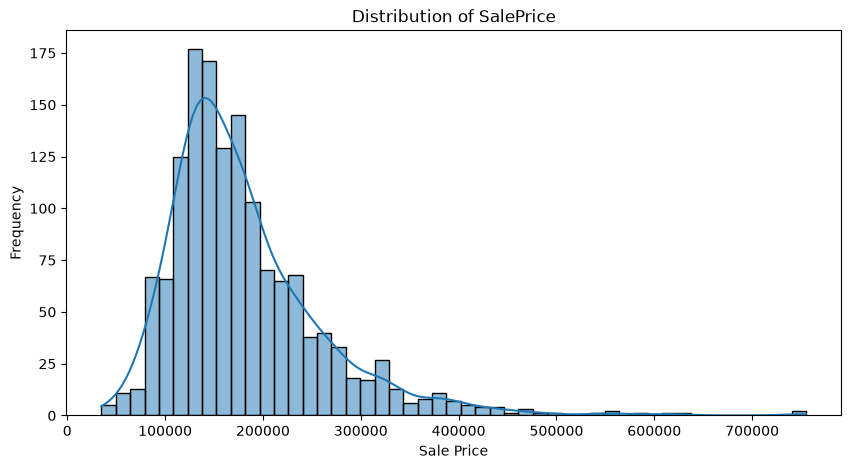

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[TARGET],
    kde=True
)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

## 3.11 Box Plot of Sale Price

A box plot is used to identify the spread of house prices and potential outliers in the target variable.

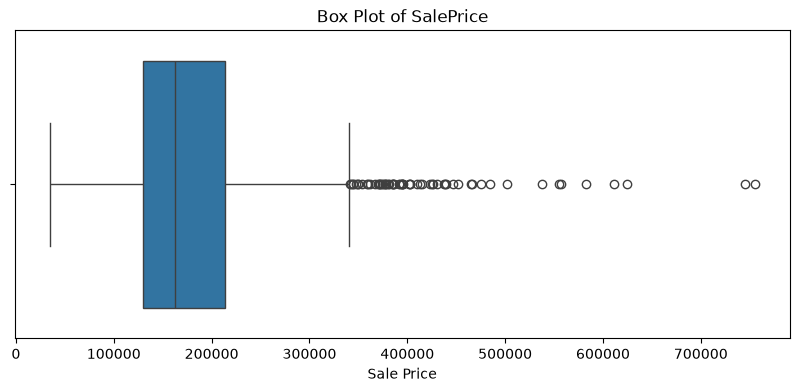

In [15]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df[TARGET]
)

plt.title("Box Plot of SalePrice")
plt.xlabel("Sale Price")

plt.show()

## 3.12 Correlation Analysis

Correlation between numerical features is examined to identify relationships between the input variables and the target variable.

This analysis will help us understand which numerical features may have stronger relationships with house prices.

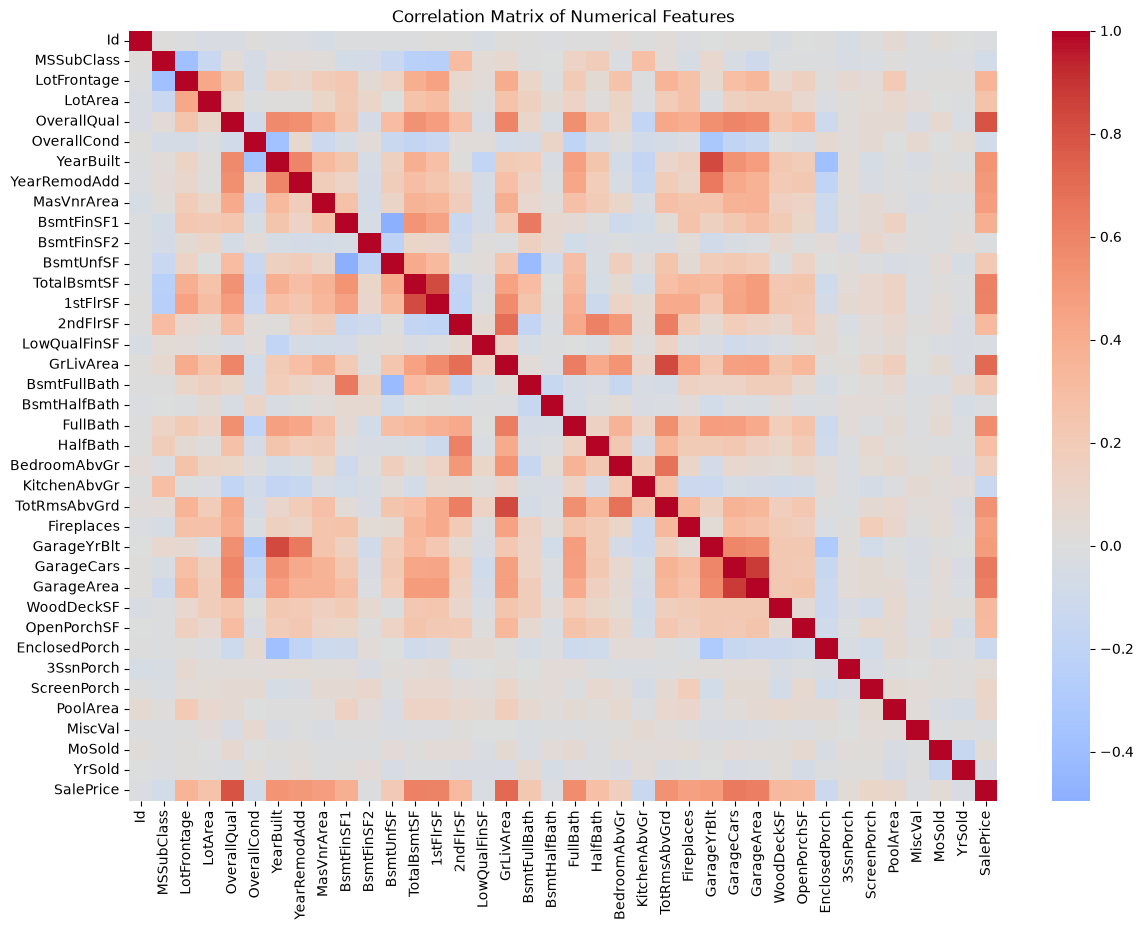

In [16]:
correlation = df[numerical_features].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

## 3.13 Features Most Correlated with SalePrice

The numerical features are ranked according to their correlation with the target variable.

This provides an initial understanding of the features that may have stronger linear relationships with house prices.

In [17]:
target_correlation = (
    df[numerical_features]
    .corr()[TARGET]
    .sort_values(ascending=False)
)

target_correlation

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

## 3.14 Top Features vs SalePrice

The strongest numerical relationships with the target variable are visualized using scatter plots.

These plots help identify whether the relationships appear approximately linear or nonlinear.

In [18]:
top_features = (
    target_correlation
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
)

print("Selected Features:")
print(top_features.tolist())

Selected Features:
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea']


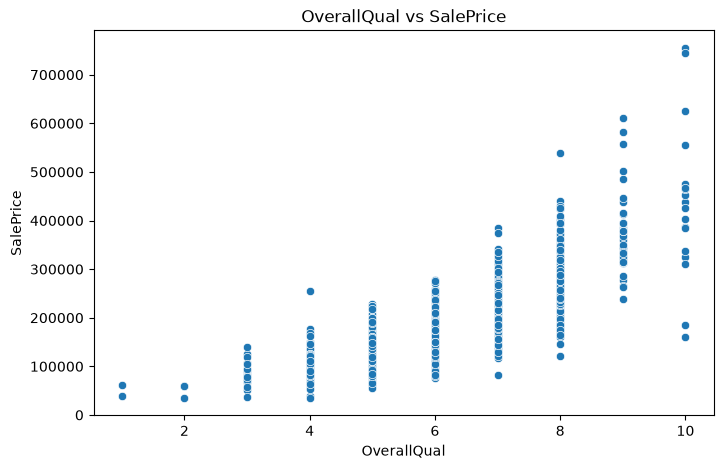

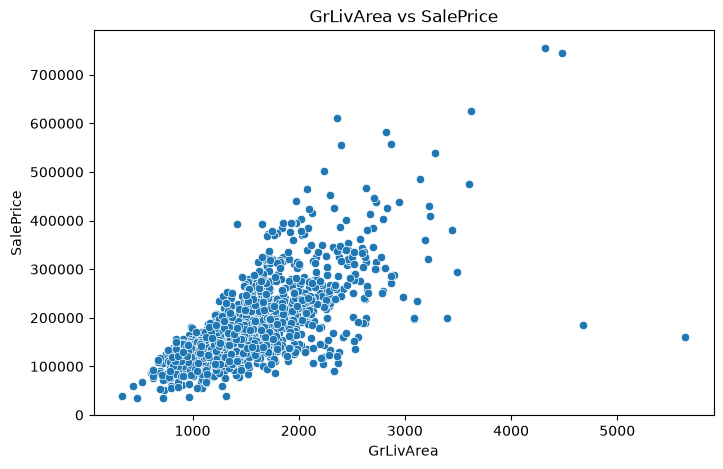

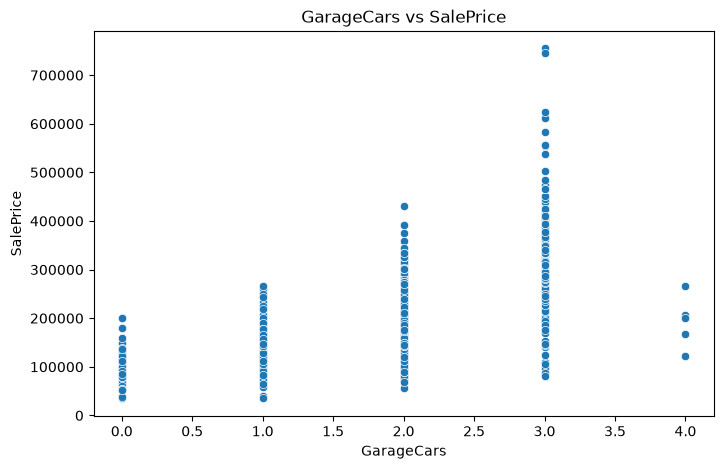

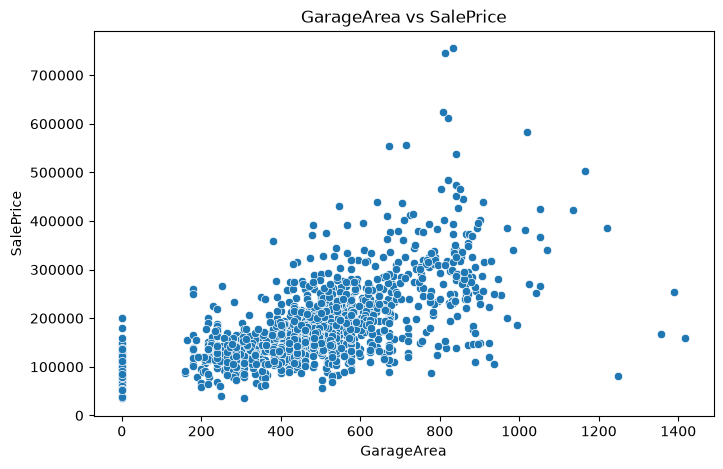

In [19]:
for feature in top_features:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y=TARGET
    )

    plt.title(f"{feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("SalePrice")

    plt.show()

## 3.15 Categorical Feature Exploration

Categorical variables can have a significant impact on house prices.

A few important categorical features are visualized against `SalePrice` to understand how different categories relate to the target.

In [20]:
# Display categorical features with a manageable number of unique values

categorical_summary = (
    df[categorical_features]
    .nunique()
    .sort_values()
)

display(categorical_summary)

Street            2
Alley             2
Utilities         2
CentralAir        2
MasVnrType        3
LandSlope         3
PavedDrive        3
GarageFinish      3
PoolQC            3
ExterQual         4
BsmtQual          4
BsmtExposure      4
BsmtCond          4
KitchenQual       4
LandContour       4
LotShape          4
Fence             4
MiscFeature       4
ExterCond         5
Electrical        5
HeatingQC         5
BldgType          5
MSZoning          5
LotConfig         5
GarageQual        5
GarageCond        5
FireplaceQu       5
Heating           6
BsmtFinType1      6
BsmtFinType2      6
RoofStyle         6
Foundation        6
GarageType        6
SaleCondition     6
Functional        7
HouseStyle        8
RoofMatl          8
Condition2        8
SaleType          9
Condition1        9
Exterior1st      15
Exterior2nd      16
Neighborhood     25
dtype: int64

In [21]:
selected_categorical_features = [
    feature
    for feature in categorical_features
    if df[feature].nunique() <= 10
][:4]

print("Selected categorical features:")
print(selected_categorical_features)

Selected categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape']


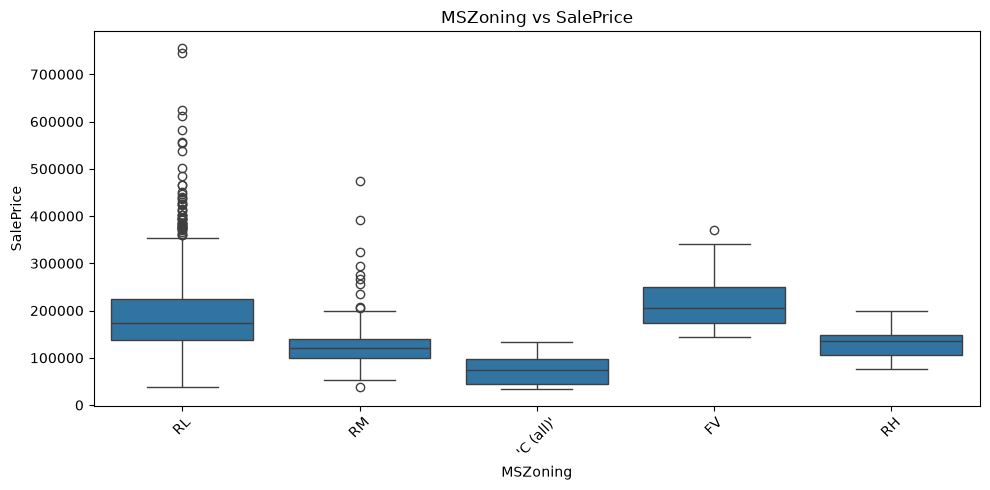

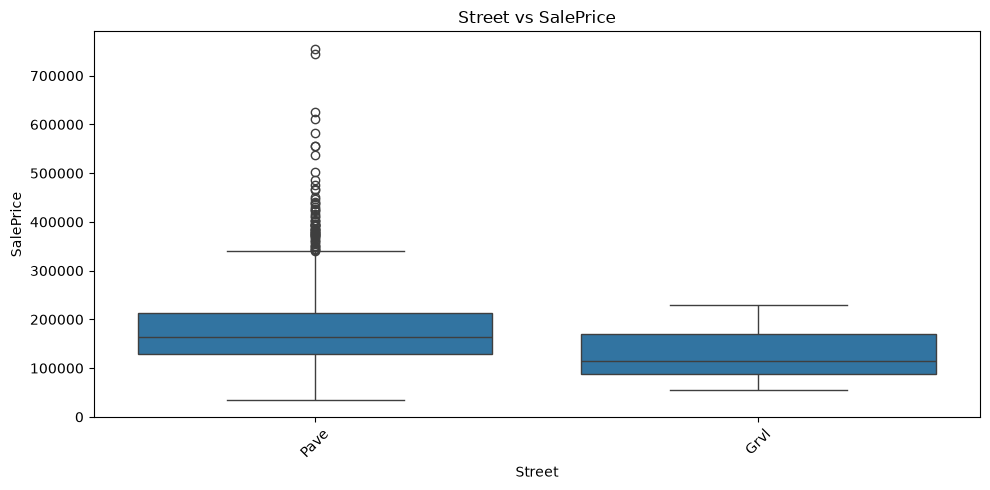

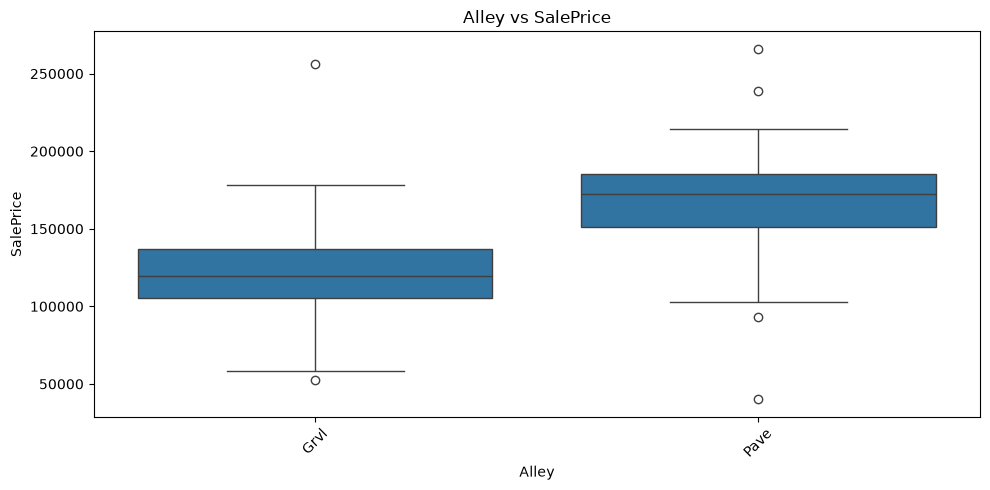

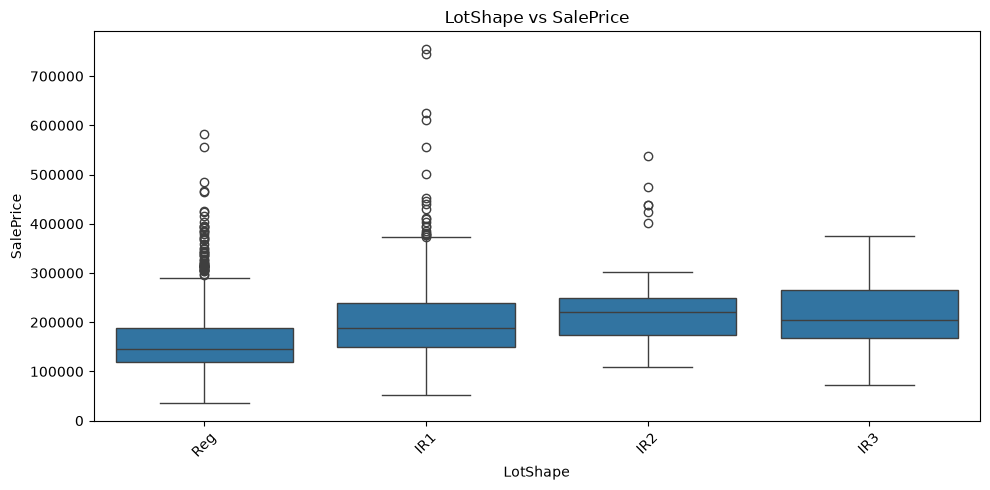

In [22]:
for feature in selected_categorical_features:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=df,
        x=feature,
        y=TARGET
    )

    plt.title(f"{feature} vs SalePrice")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## 3.16 Initial Data Quality Observations

Based on the inspection and exploratory analysis above, we identify the major data-quality and preprocessing requirements.

The following aspects will be considered in the next stage:

- Missing values require appropriate treatment.
- Numerical and categorical features require different preprocessing strategies.
- Categorical variables need to be encoded before model training.
- Numerical variables will be scaled where appropriate.
- Potential outliers should be investigated before final model training.
- The target variable distribution should be considered when interpreting model performance.
- Feature engineering opportunities will be evaluated based on domain relevance and model performance.

## 4. Data Cleaning and Preprocessing

### Objective

This section prepares the Ames Housing dataset for machine learning.

The workflow includes:
- Loading the dataset
- Removing non-predictive identifier columns
- Handling missing values according to the meaning of each feature
- Creating useful derived features
- Separating features and target
- Splitting the data into training and testing sets
- Building a preprocessing pipeline
- Imputing missing values
- Scaling numerical features
- Encoding categorical features
- Verifying the transformed data

The preprocessing steps are designed to avoid data leakage by fitting learned transformations only on the training data.


## 4.1 Initial Data Quality Check

Before cleaning the data, we verify the number of duplicate rows and inspect the current missing-value situation.

Duplicate rows are removed only if they actually exist.


In [23]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found.")


Duplicate rows found: 0
No duplicate rows found.


## 4.2 Remove the Identifier Column

`Id` is an identifier assigned to each record. It does not describe a property characteristic and therefore should not be used as a predictive feature.

We remove it before model training.


In [24]:
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

print("Identifier column removed.")
print(f"Current number of columns: {df.shape[1]}")


Identifier column removed.
Current number of columns: 80


## 4.3 Handle Missing Values Representing Feature Absence

In the Ames Housing dataset, several categorical missing values have a meaningful interpretation: the corresponding feature is not present.

For example:
- Missing `PoolQC` means the property has no pool.
- Missing `GarageType` means there is no garage.
- Missing basement-quality fields mean there is no basement.

These values are therefore represented as `"None"` rather than treating them as ordinary unknown values.


In [25]:
absence_categorical = [
    "Alley",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

absence_categorical = [
    col for col in absence_categorical
    if col in df.columns
]

df[absence_categorical] = df[absence_categorical].fillna("None")

print("Categorical feature-absence values handled.")
print(f"Columns updated: {len(absence_categorical)}")


Categorical feature-absence values handled.
Columns updated: 14


## 4.4 Handle Numerical Features Where Zero Represents Absence

Some numerical variables naturally use `0` to represent the absence of a feature, such as masonry veneer area or basement/garage measurements.

We do not replace these valid zeros because they contain useful information for the model.

In [26]:
zero_as_absence = [
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageCars",
    "GarageArea",
    "PoolArea"
]

existing_zero_features = [
    col for col in zero_as_absence
    if col in df.columns
]

print("Valid zero-valued absence features:")
print(existing_zero_features)


Valid zero-valued absence features:
['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea', 'PoolArea']


## 4.5 Inspect Remaining Missing Values

After handling missing values whose meaning is known, we inspect the remaining missing values.

The remaining missing values will be handled by the preprocessing pipeline using training-data statistics rather than manually filling them before the train/test split.


In [27]:
remaining_missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("No missing values remain.")
else:
    missing_summary = pd.DataFrame({
        "Missing Count": remaining_missing,
        "Missing Percentage": (
            remaining_missing / len(df) * 100
        ).round(2)
    })
    display(missing_summary)


,Missing Count,Missing Percentage
MasVnrType,872,59.73
LotFrontage,259,17.74
GarageYrBlt,81,5.55
MasVnrArea,8,0.55
Electrical,1,0.07


## 4.6 Feature Engineering

Additional features are created from existing property information.

These features provide the model with more directly interpretable relationships:
- `HouseAge`: age of the house at the time of sale
- `RemodAge`: years since the most recent remodeling
- `TotalSF`: total basement and above-ground living area
- `TotalBathrooms`: weighted combination of full and half bathrooms
- `TotalPorchSF`: combined porch/deck area

These transformations are deterministic and do not use the target variable.


In [28]:
feature_engineering_transformer = FunctionTransformer(
    feature_engineering
)

## 4.7 Correct the Data Types of Categorical Features

Some Ames Housing variables are stored as integers even though their values represent categories rather than continuous measurements.

`MSSubClass` is treated as categorical because its numeric codes identify building classes.

`MoSold` is also treated as categorical because the month number represents a calendar category rather than a continuous measurement.


In [29]:
df["MSSubClass"] = df["MSSubClass"].astype(str)
df["MoSold"] = df["MoSold"].astype(str)

print("MSSubClass and MoSold converted to categorical variables.")
print(df[["MSSubClass", "MoSold"]].dtypes)


MSSubClass and MoSold converted to categorical variables.
MSSubClass    object
MoSold        object
dtype: object


## 4.8 Separate Features and Target

`SalePrice` is the target variable.

All remaining columns are used as input features. The target is separated before the train/test split so that it is never passed through the feature preprocessing pipeline.


In [30]:
TARGET = "SalePrice"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target variable: {TARGET}")


Feature matrix shape: (1460, 79)
Target shape: (1460,)
Target variable: SalePrice


## 4.9 Identify Numerical and Categorical Features

The feature columns are divided into numerical and categorical groups.

This separation allows us to apply different preprocessing operations to each group.


In [31]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Number of numerical features   : {len(numerical_features)}")
print(f"Number of categorical features : {len(categorical_features)}")

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Number of numerical features   : 34
Number of categorical features : 45

Numerical features:
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold']

Categorical features:
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Elect

## 4.10 Train-Test Split

The dataset is divided into training and testing sets.

The split is performed before fitting any learned preprocessing step. This prevents information from the test set from influencing imputation or scaling parameters.


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")


Training samples: 1168
Testing samples : 292


## 4.11 Build the Numerical Preprocessing Pipeline

Numerical features are processed using two steps:

1. Missing values are replaced with the median calculated from the training data.
2. `StandardScaler` standardizes the numerical features.

Standardization is useful for models that are sensitive to feature scale and also demonstrates the required scaling stage of the ML pipeline.


In [33]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created.")


Numerical preprocessing pipeline created.


## 4.12 Build the Categorical Preprocessing Pipeline

Categorical features are processed using:

1. Most-frequent-value imputation for any remaining missing categorical values.
2. One-hot encoding to convert categorical values into numerical features.

`handle_unknown="ignore"` ensures that the prediction service can handle a category that was not present during model training.


In [34]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")


Categorical preprocessing pipeline created.


## 4.13 Combine Preprocessing with ColumnTransformer

The numerical and categorical pipelines are combined using `ColumnTransformer`.

This creates a single preprocessing object that applies the correct transformation to each feature group.


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("ColumnTransformer created successfully.")


ColumnTransformer created successfully.


## 4.14 Fit the Preprocessor on Training Data

The preprocessing object is fitted only on `X_train`.

It is then used to transform both the training and testing sets.

This is an important step for preventing data leakage because the test data does not influence the learned imputation or scaling parameters.


In [36]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessor fitted successfully.")
print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed testing shape : {X_test_processed.shape}")


Preprocessor fitted successfully.
Processed training shape: (1168, 324)
Processed testing shape : (292, 324)


## 4.15 Verify the Processed Data

We inspect the transformed feature matrix to confirm that preprocessing produced a numerical representation suitable for machine learning models.


In [37]:
print("Processed training data type:", type(X_train_processed))
print("Processed testing data type :", type(X_test_processed))

print("\nFirst training sample:")
print(X_train_processed[0])

print("\nNumber of transformed features:")
print(X_train_processed.shape[1])


Processed training data type: <class 'scipy.sparse._csr.csr_matrix'>
Processed testing data type : <class 'scipy.sparse._csr.csr_matrix'>

First training sample:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 79 stored elements and shape (1, 324)>
  Coords	Values
  (0, 0)	-0.012468363176367587
  (0, 1)	-0.21289571021689285
  (0, 2)	-0.8204445578548297
  (0, 3)	0.37221730085603477
  (0, 4)	-0.4554689634533773
  (0, 5)	-1.3460630279925625
  (0, 6)	-0.59788870008087
  (0, 7)	1.0372686113776926
  (0, 8)	-0.28550406121847727
  (0, 9)	-0.40028164505613256
  (0, 10)	0.5726121928947197
  (0, 11)	0.3742352301895073
  (0, 12)	-0.8019229244046748
  (0, 13)	-0.11899866377895676
  (0, 14)	-0.40709314807972335
  (0, 15)	1.1053195824048596
  (0, 16)	-0.24287002311294137
  (0, 17)	-1.0555657250367967
  (0, 18)	-0.7640975231923183
  (0, 19)	0.13621832007914325
  (0, 20)	-0.2127571124887476
  (0, 21)	-0.9645659090752412
  (0, 22)	-0.9585921495629545
  (0, 23)	-0.9044027695231686
  (0, 24)

## 4.16 Check for Remaining Missing Values

After preprocessing, there should be no missing values in the transformed training and testing matrices.

This confirms that the imputation stages are functioning correctly.


In [38]:
train_missing = np.isnan(
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
).sum()

test_missing = np.isnan(
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
).sum()

print(f"Missing values in processed training data: {train_missing}")
print(f"Missing values in processed testing data : {test_missing}")


Missing values in processed training data: 0
Missing values in processed testing data : 0


## 4.17 Summary of the Preprocessing Pipeline

The preprocessing workflow developed in this notebook is:

```text
Raw Housing Data
       |
       +-- Remove Id
       |
       +-- Handle feature-absence values
       |
       +-- Feature Engineering
       |
       +-- Train/Test Split
       |
       +---------------------------+
       |                           |
 Numerical Features        Categorical Features
       |                           |
 Median Imputation         Most-Frequent Imputation
       |                           |
 StandardScaler             OneHotEncoder
       |                           |
       +-------------+-------------+
                     |
              Processed Features
```

The resulting `preprocessor` will later be combined with a regression model inside a single scikit-learn `Pipeline`.


In [39]:
print("Data cleaning and preprocessing stage completed.")
print(f"Original dataset rows : {len(df)}")
print(f"Training rows         : {len(X_train)}")
print(f"Testing rows          : {len(X_test)}")
print(f"Original input features: {X.shape[1]}")
print(f"Transformed features   : {X_train_processed.shape[1]}")


Data cleaning and preprocessing stage completed.
Original dataset rows : 1460
Training rows         : 1168
Testing rows          : 292
Original input features: 79
Transformed features   : 324


## 4.18 Conclusion

The Ames Housing dataset has been cleaned and prepared for machine learning.

The main steps completed are:

- Removed the non-predictive `Id` column.
- Handled categorical missing values that represent absent property features.
- Preserved meaningful zero values.
- Created additional housing-related features.
- Corrected categorical data types.
- Separated features and target.
- Split the dataset into training and testing sets.
- Built separate numerical and categorical preprocessing pipelines.
- Applied median imputation and standard scaling to numerical features.
- Applied categorical imputation and one-hot encoding to categorical features.
- Fitted preprocessing only on the training data to avoid data leakage.

The next stage is **model training and evaluation**, where multiple regression models will be trained using this preprocessing pipeline and compared using MAE, RMSE, and R².


In [40]:
print("Ready for the model training and evaluation stage.")

Ready for the model training and evaluation stage.


## 5. Model Training and Evaluation

This section covers the complete machine learning model development stage.

The workflow includes:
- Training multiple regression models
- Comparing model performance
- Hyperparameter tuning using cross-validation
- Evaluating the tuned model on unseen test data
- Performing prediction and residual analysis

## 5.1 Define Candidate Models

In this section, multiple regression models are defined to establish a performance comparison for the house price prediction task.

The selected models include Linear Regression, Ridge Regression, Random Forest Regressor, and Gradient Boosting Regressor. These models provide a range of linear and tree-based approaches for evaluating the effectiveness of different learning algorithms on the prepared dataset.

In [41]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = []
pipelines = {}

## 5.2 Train and Evaluate Models

Each candidate model is integrated with the preprocessing pipeline using a Scikit-learn Pipeline.

The models are trained using the training dataset and evaluated on the unseen test dataset. Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score are calculated to measure prediction accuracy and overall model performance.

In [42]:
for name, model in models.items():

    pipe = Pipeline([
    ("feature_engineering", feature_engineering_transformer),
    ("preprocessor", preprocessor),
    ("model", model)
])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

    pipelines[name] = pipe

## 5.3 Compare Model Performance

The performance of all candidate models is collected and organized into a comparison table.

The models are compared using MAE, RMSE, and R² Score. RMSE is used as the primary metric for comparing the regression models because it gives greater importance to larger prediction errors.

In [43]:
results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

results_df

,Model,MAE,RMSE,R2
0,Gradient Boosting,16782.197416,26615.064976,0.907649
1,Random Forest,17283.904053,28600.615592,0.893356
2,Ridge Regression,19032.027757,30836.094860,0.876033
3,Linear Regression,21258.244211,69359.741736,0.372807


## 5.4 Visualize Model Comparison

The model performance is visualized to make the differences between the candidate models easier to interpret.

The comparison plot provides a graphical representation of the RMSE values obtained by the different regression models and helps identify the models that provide stronger predictive performance on the test dataset.

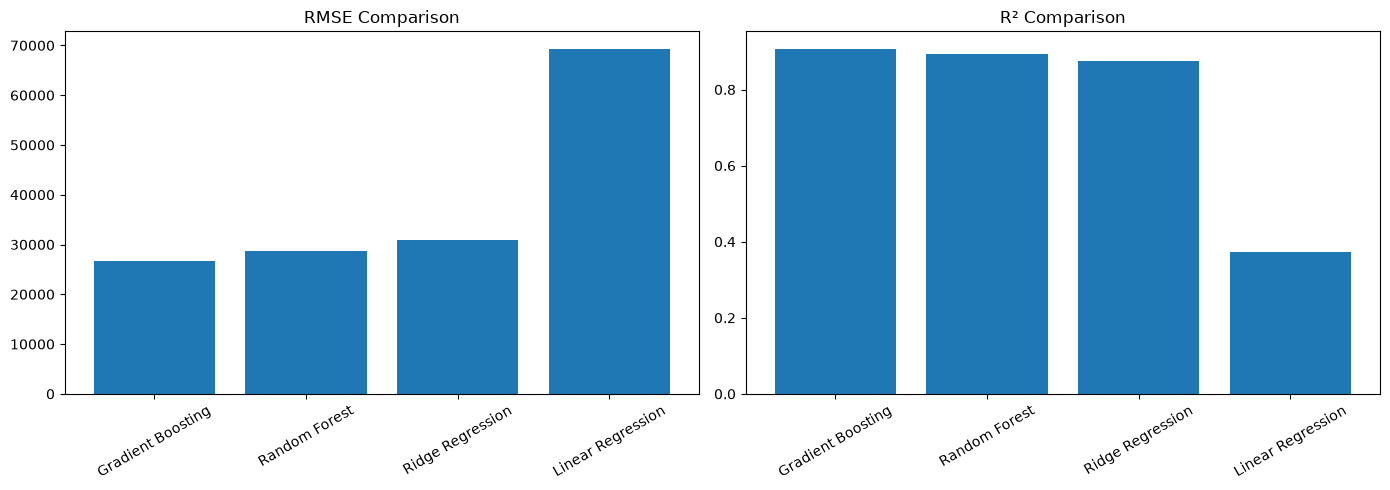

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(results_df["Model"], results_df["RMSE"])
ax[0].set_title("RMSE Comparison")
ax[0].tick_params(axis="x", rotation=30)

ax[1].bar(results_df["Model"], results_df["R2"])
ax[1].set_title("R² Comparison")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 5.5 Hyperparameter Tuning

Hyperparameter tuning is performed on the Gradient Boosting Regressor to improve its predictive performance.

GridSearchCV is used with 5-fold cross-validation to evaluate different combinations of the number of estimators, learning rate, maximum tree depth, and minimum samples required for splitting. The model configuration with the best cross-validation RMSE is selected.

In [45]:
gb_pipe = Pipeline(
    [
        ("feature_engineering", feature_engineering_transformer),
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42)),
    ]
)
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
}
grid = GridSearchCV(
    gb_pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV RMSE: 28390.875808943336


## 5.6 Display Best Parameters

The best hyperparameter configuration identified by GridSearchCV is displayed along with its corresponding cross-validation RMSE.

These parameters represent the configuration selected during the tuning process based on the RMSE scoring metric.

In [46]:
print("Best parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid.best_score_)

Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Best Cross-Validation RMSE:
28390.875808943336


## 5.7 Final Model Selection

The best estimator returned by GridSearchCV is selected as the final machine learning pipeline.

The selected pipeline contains both the data preprocessing steps and the tuned Gradient Boosting Regressor, ensuring that the same preprocessing procedure is automatically applied whenever the model is used for prediction.

In [47]:
final_pipeline = grid.best_estimator_

print("Final pipeline selected from GridSearchCV.")
print("Best parameters:")
print(grid.best_params_)

Final pipeline selected from GridSearchCV.
Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 300}


## 5.8 Final Test Evaluation

The selected final model is evaluated on the unseen test dataset to measure its final predictive performance.

Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score are calculated to provide a complete evaluation of the final model.

In [48]:
pred = final_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 16,782.20
RMSE : 26,615.06
R²   : 0.9076


## 5.9 Actual vs Predicted Analysis

The actual SalePrice values are compared with the prices predicted by the final model.

An Actual vs Predicted plot is used to visually examine how closely the predictions follow the actual house prices. Predictions closer to the reference relationship indicate better agreement between the predicted and actual values.

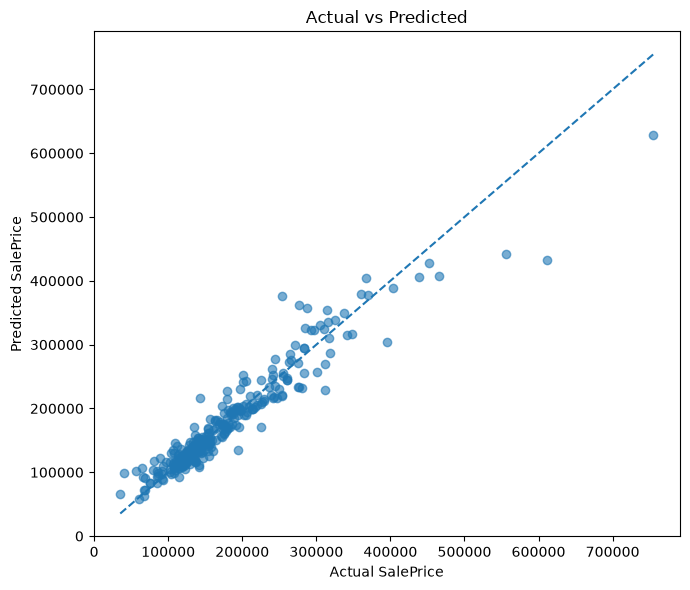

In [49]:
plt.figure(figsize=(7,6))
plt.scatter(y_test,pred,alpha=.6)
lo=min(y_test.min(),pred.min()); hi=max(y_test.max(),pred.max())
plt.plot([lo,hi],[lo,hi],"--")
plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted"); plt.tight_layout(); plt.show()

## 5.10 Residual Analysis

Residual analysis is performed to examine the prediction errors produced by the final model.

The residuals are calculated as the difference between the actual and predicted SalePrice values. A residual plot is used to identify the distribution and patterns of prediction errors and to assess whether any noticeable systematic patterns remain.

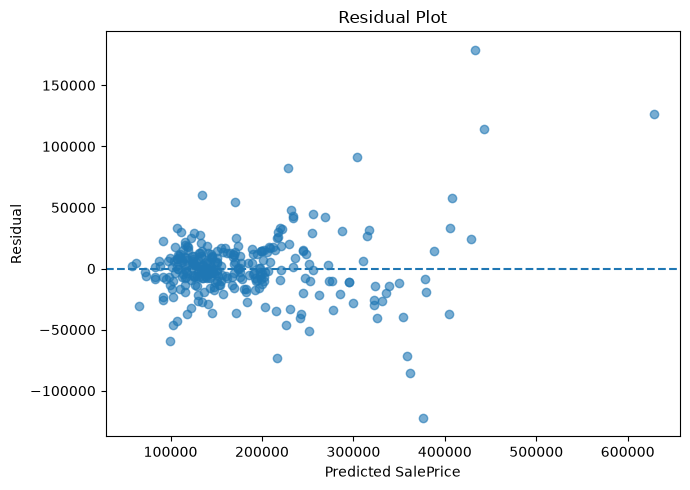

In [50]:
residuals=y_test-pred
plt.figure(figsize=(7,5))
plt.scatter(pred,residuals,alpha=.6)
plt.axhline(0,linestyle="--")
plt.xlabel("Predicted SalePrice"); plt.ylabel("Residual")
plt.title("Residual Plot"); plt.tight_layout(); plt.show()

## 5.11 Conclusion

The candidate regression models were trained and evaluated using consistent preprocessing and multiple performance metrics.

Gradient Boosting was selected for hyperparameter tuning based on the model comparison results. GridSearchCV was then used to identify a suitable combination of hyperparameters through 5-fold cross-validation.

The tuned Gradient Boosting pipeline was evaluated on the unseen test dataset using MAE, RMSE, and R² Score. Actual vs Predicted and residual analyses were also performed to further examine the model's prediction behavior.

The resulting pipeline contains both preprocessing and the trained regression model, making it suitable for persistence and later deployment.

## 6. Model Persistence

This section focuses on saving and verifying the trained machine learning model for future use.

The complete preprocessing and model pipeline is persisted as a single artifact so that the same data transformations and trained model can be reused during prediction and deployment.

The workflow includes:
- Creating a dedicated directory for model artifacts
- Saving the complete trained ML pipeline using Joblib
- Saving model metadata and evaluation results
- Reloading the saved pipeline
- Verifying that the reloaded pipeline produces the same predictions as the original pipeline

The persisted model artifact will serve as the foundation for the next stage of the assignment, where the model will be integrated with a FastAPI application and containerized using Docker.

## 6.1 Create Model Directory

A dedicated model directory is created to store the trained machine learning pipeline and its associated metadata.

Keeping the model artifacts separate from the source code and dataset helps maintain a clean project structure and makes the trained model easier to reuse during deployment.

In [51]:
os.makedirs("../model", exist_ok=True)

## 6.2 Save Complete ML Pipeline

The complete trained machine learning pipeline is saved using Joblib.

The saved pipeline contains the preprocessing transformations and the trained Gradient Boosting model together. This allows new input data to pass through the same preprocessing steps automatically before generating predictions.

In [52]:
model_path = "../model/house_price_pipeline.joblib"
joblib.dump(final_pipeline, model_path)

['../model/house_price_pipeline.joblib']

## 6.3 Save Model Metadata

Important information about the trained model is stored separately as metadata.

The metadata includes the model name, target variable, input feature information, number of numerical and categorical features, best hyperparameters, and test-set evaluation metrics. This information provides useful details about the saved model without requiring the pipeline to be loaded first.

In [53]:
metadata = {
    "dataset": "Ames Housing / House Prices",
    "target": "SalePrice",
    "problem_type": "Regression",

    "training_samples": len(X_train),
    "testing_samples": len(X_test),

    "input_features": len(X_train.columns),
    "numerical_features": len(numerical_features),
    "categorical_features": len(categorical_features),

    "model": "GradientBoostingRegressor",

    "parameters": grid.best_params_,

    "best_cv_rmse": float(-grid.best_score_),

    "MAE": float(mae),
    "RMSE": float(rmse),
    "R2": float(r2),

    "artifact": "house_price_pipeline.joblib"
}
with open("../model/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)
print("Saved:", model_path)

Saved: ../model/house_price_pipeline.joblib


## 6.4 Reload Saved Pipeline

The persisted machine learning pipeline is loaded back into memory using Joblib.

Reloading the saved pipeline verifies that the stored model artifact can be successfully restored and used independently of the original training process.

In [54]:
loaded = joblib.load(model_path)

## 6.5 Verify Saved Pipeline

The reloaded pipeline is used to generate predictions on the test dataset.

The predictions produced by the reloaded pipeline are compared with the predictions generated before saving. This verifies that the complete preprocessing and model pipeline has been persisted correctly and can reproduce the same predictions after being reloaded.

In [55]:
loaded_pred = loaded.predict(X_test)

difference = np.max(np.abs(pred - loaded_pred))

print("Maximum prediction difference:", difference)

if np.allclose(pred, loaded_pred):
    print("Verification successful.")
else:
    print("Check saved artifact.")

Maximum prediction difference: 0.0
Verification successful.


### 6.6 Conclusion

The complete machine learning pipeline was successfully persisted using Joblib.

The saved pipeline includes:
- Feature engineering
- Numerical preprocessing
- Categorical preprocessing
- Gradient Boosting regression model

The saved pipeline was successfully reloaded and tested on the test dataset. The maximum prediction difference between the original and reloaded pipelines was 0.0, confirming that the persisted model works correctly and can be used for deployment.

# 7. Conclusion

This notebook implemented a complete machine learning workflow for house price prediction using the Ames Housing dataset.

The workflow began with dataset loading and exploratory data analysis, where the structure of the dataset, data types, missing values, duplicate records, numerical statistics, categorical features, target distribution, correlations, and potential data quality issues were examined.

The data was then cleaned and prepared by removing the identifier column, handling missing values that represented feature absence, preserving meaningful numerical zeros, performing feature engineering, correcting categorical data types, and separating the features from the target variable. A consistent preprocessing pipeline was created using numerical imputation and scaling together with categorical imputation and one-hot encoding.

Multiple regression models were trained and compared using MAE, RMSE, and R² Score. Gradient Boosting was selected for further optimization, and GridSearchCV with 5-fold cross-validation was used to identify suitable hyperparameters.

The tuned final model was evaluated on the unseen test dataset, followed by Actual vs Predicted and residual analysis to examine its prediction behavior.

Finally, the complete preprocessing and trained model pipeline was persisted using Joblib along with metadata describing the model configuration and evaluation results. The saved pipeline was reloaded and verified to ensure that it could successfully reproduce predictions.

Overall, the notebook establishes a complete and reproducible machine learning pipeline from raw data exploration and preprocessing through model training, evaluation, tuning, and model persistence. The resulting model artifact can be used as the foundation for the next stage of the assignment: serving the model through FastAPI and containerizing the application using Docker.